# Agripredict

### Importation des librairies

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Chargement du dataset et nettoyage

In [7]:
df = pd.read_csv('../data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [16]:

df.info()
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')


In [11]:
print(df["label"].unique())

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str


In [13]:
# Vérifions le nombre de doublons dans le dataset

print("Doublons :", df.duplicated().sum())

Doublons : 0


In [ ]:
# Vérifions le nombre de cultures et leur répartition

print(df['label'].nunique(), "cultures différentes")
df['label'].value_counts()

22 cultures différentes


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

### Création d'un champ de rendement kg/ha "yield_kg_ha" dans le dataset

In [19]:
'''
Le dataset ne contient pas de rendement réel car c'est un dataset de classification a la base.
Je vais donc simuler une variable continue. Le rendement dépend des nutriments et des conditions
climatiques à travers une somme pondérée et un peu de hasard
rendement = combinaison des nutriments + pluie + humidité, avec un poids pour chaque facteur et une
part de hasard

'''

np.random.seed(42) # cela va permettre que le résultat soit toujours le même si on relance

df["yield_kg_ha"] = (
    df["N"] * 15 +  #plus d'azote entraîne plus de rendement
    df["P"] * 10 +
    df["K"] * 10 +
    df["rainfall"] * 5 +    #plus de pluie entraîne plus de rendement  
    df["humidity"] * 8 +
    np.random.normal(0, 200, size=len(df)) #du bruit pour la variabilité naturelle des données
    
)

df[["N", "P", "K", "rainfall", "humidity", "yield_kg_ha"]].head()

,N,P,K,rainfall,humidity,yield_kg_ha
0,90,42,43,202.935536,82.002744,3970.042465
1,85,58,41,226.655537,80.319644,4013.181979
2,60,55,44,263.964248,82.320763,3997.925049
3,74,35,40,242.864034,80.158363,4020.193043
4,78,42,42,262.717340,81.604873,3929.595011


In [20]:
df["yield_kg_ha"].describe()

count    2200.000000
mean     2869.567618
std       975.010948
min      1061.377374
25%      2065.443646
50%      2724.283992
75%      3521.403418
max      5560.259881
Name: yield_kg_ha, dtype: float64

### Analyse exploratoire et graphiques

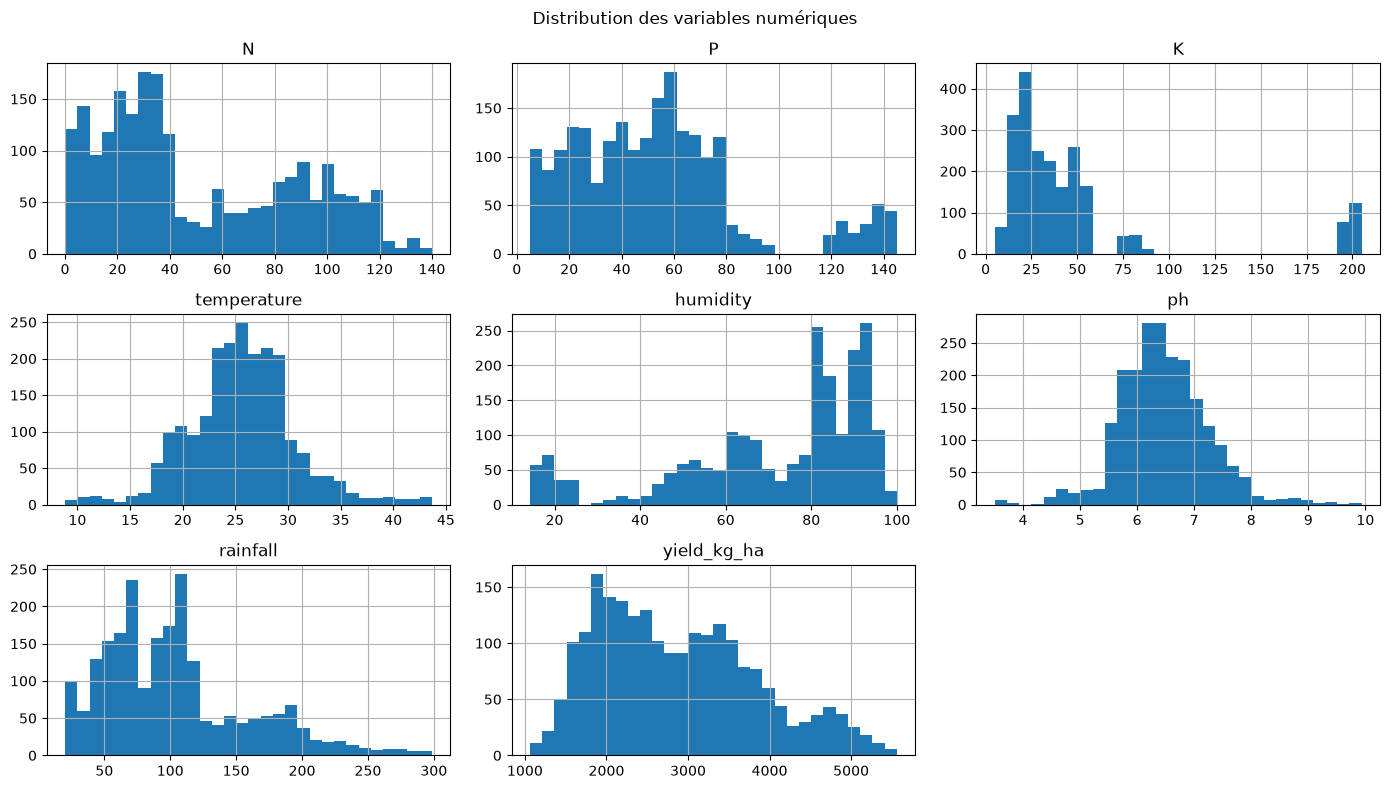

In [21]:
# Commençons par observer la distribution des variables numériques pour voir si elles sont équilibrées,
# ou si il y a des valeurs extrêmes, normales etc

colonnes_numeriques = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "yield_kg_ha"]

df[colonnes_numeriques].hist(figsize=(14, 8), bins=30)
plt.suptitle("Distribution des variables numériques")
plt.tight_layout()
plt.show()


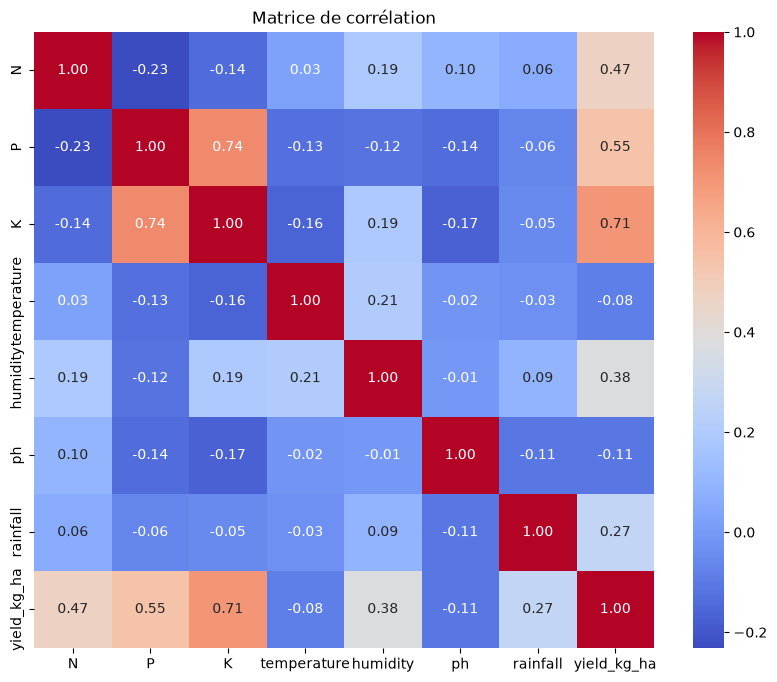

In [22]:
# Maintenant étudions la corrélation avec corr() qui calcule le coefficient de corrélation de Pearson
# entre chaque paire de variables, plus il est proche de 1, plus la corrélation est forte

correlation_matrix = df[colonnes_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


In [27]:
correlation_matrix['yield_kg_ha'].sort_values(ascending=False)

yield_kg_ha    1.000000
K              0.705022
P              0.546413
N              0.469641
humidity       0.377157
rainfall       0.273234
temperature   -0.083230
ph            -0.108210
Name: yield_kg_ha, dtype: float64

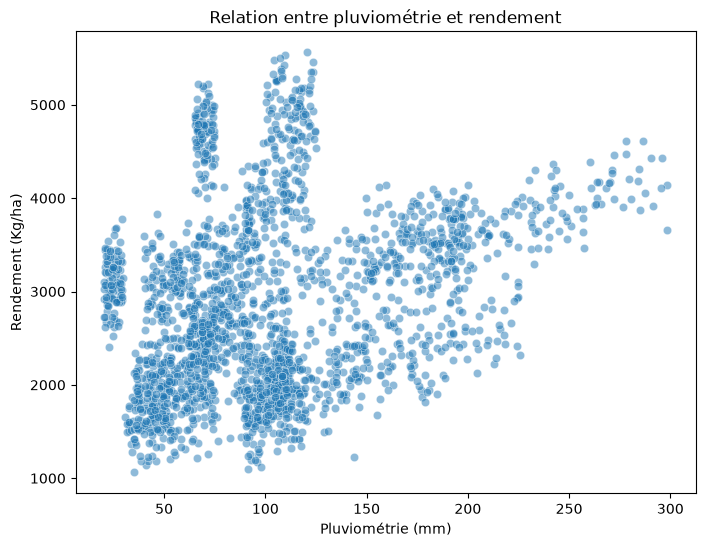

In [28]:
# Passons a la relation pluie/rendement
# Pour ce faire, nous allons utiliser scatterplot/nuage de point qui permet de voir visuellement
# s'il y a une tendance

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="rainfall", y="yield_kg_ha", alpha=0.5)
plt.title("Relation entre pluviométrie et rendement")
plt.xlabel("Pluviométrie (mm)")
plt.ylabel("Rendement (Kg/ha)")
plt.show()

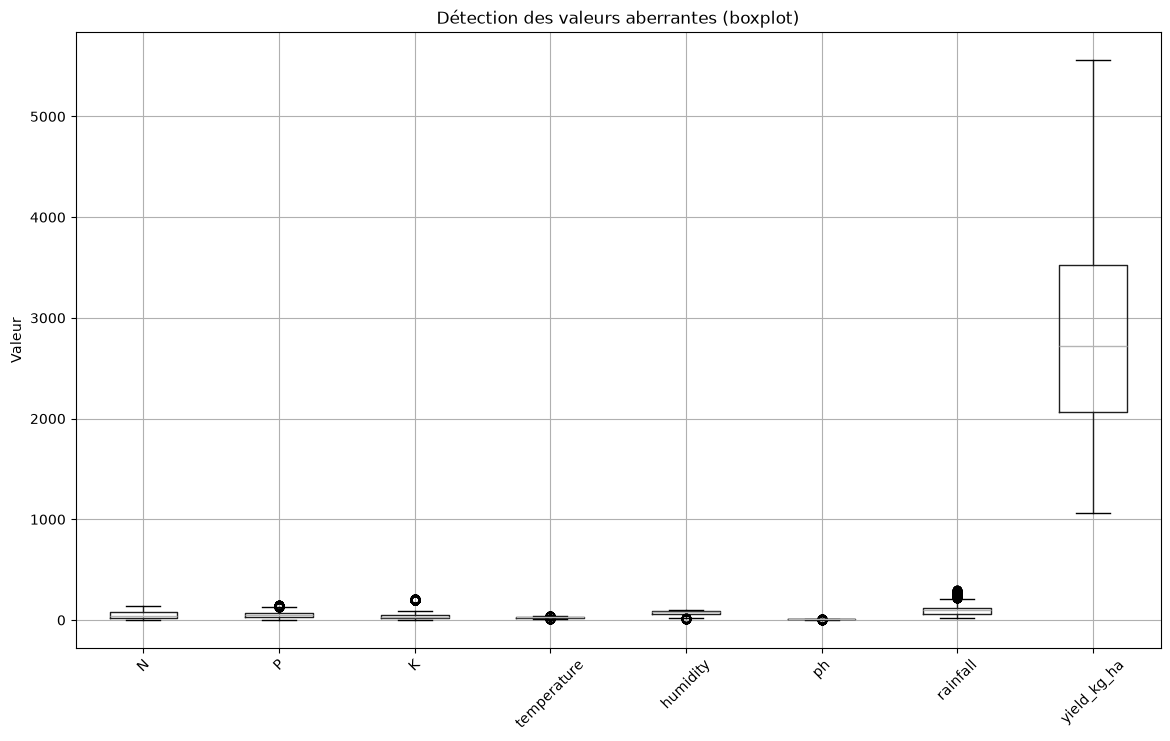

In [36]:
# Passons a la visualisation des outliers potentiels via boxplot
# Chaque boite montre la distribution d'une variable et ses valeurs extremes

plt.figure(figsize=(14, 8))
df[colonnes_numeriques].boxplot()
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes (boxplot)")
plt.ylabel("Valeur")
plt.show()

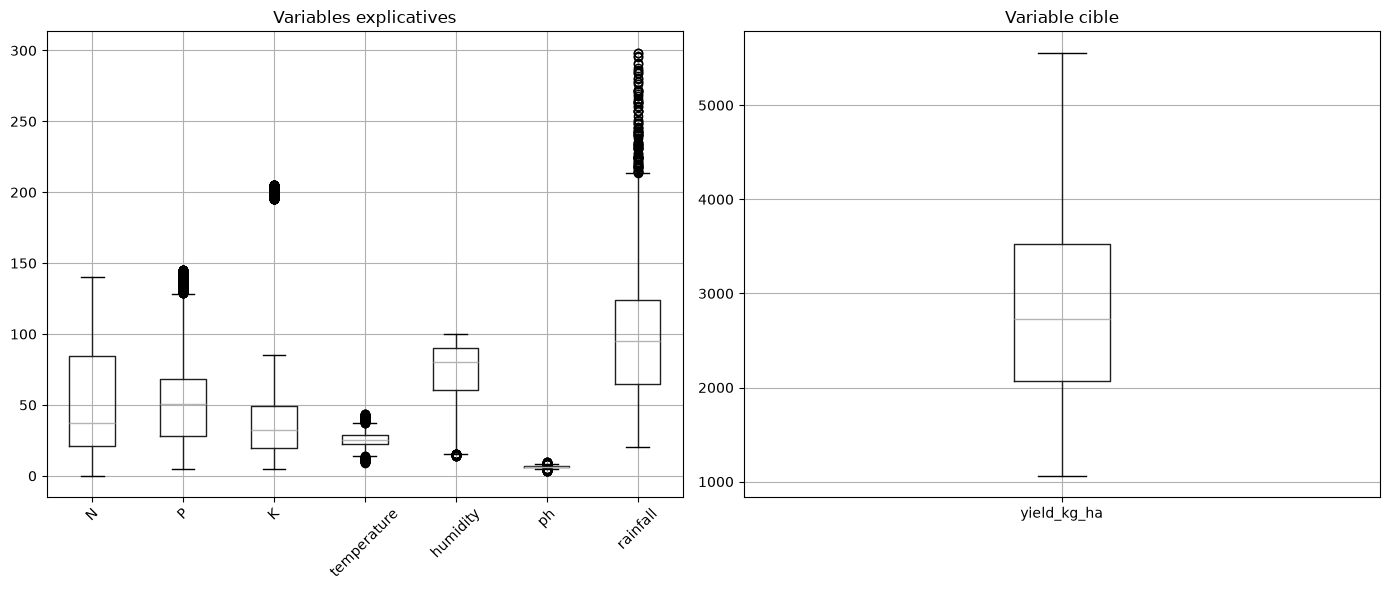

In [37]:
# On sépare les variables par échelle pour une lecture plus claire
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Groupe 1 : variables à petite échelle
df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].boxplot(ax=axes[0])
axes[0].set_title("Variables explicatives")
axes[0].tick_params(axis='x', rotation=45)

# Groupe 2 : la variable cible, à part (échelle différente)
df[['yield_kg_ha']].boxplot(ax=axes[1])
axes[1].set_title("Variable cible")

plt.tight_layout()
plt.show()